### Ethiopian Birr Banknote Denomination Recognition Using CNN

This project uses a Convolutional Neural Network (CNN) to recognize Ethiopian Birr banknote denominations from images.

The model classifies banknotes into five denominations:
- 5 Birr
- 10 Birr
- 50 Birr
- 100 Birr
- 200 Birr

The dataset contains images of both the front and back of each banknote. The goal is to train, evaluate, and save a deep learning model that can automatically identify the denomination of a given banknote image.

#### Import the libraries

In [1]:
! pip install numpy tensorflow pandas matplotlib seaborn scikit-learn Pillow
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


#### Define Dataset Path

In [2]:
TRAIN_DIR = "../data/Ethiopian_Currency/train"
TEST_DIR = "../data/Ethiopian_Currency/test"

NATURAL_IMAGES_DIR = "../data/Natural_Images"

print("Training directory exists:", os.path.exists(TRAIN_DIR))
print("Testing directory exists:", os.path.exists(TEST_DIR))
print(
    "Natural Images directory exists:",
    os.path.exists(NATURAL_IMAGES_DIR)
)

Training directory exists: True
Testing directory exists: True
Natural Images directory exists: True


#### Explore the folders

In [3]:
print("Training folders:")
print(os.listdir(TRAIN_DIR))

print("\nTesting folders:")
print(os.listdir(TEST_DIR))

print('\n Natural Images Categories')
print(os.listdir(NATURAL_IMAGES_DIR))

Training folders:
['background', '10back', '.DS_Store', '100back', '200front', '10front', '50front', '200back', '50back', '5back', '100front', '5front']

Testing folders:
['background', '10back', '.DS_Store', '100back', '200front', '10front', '50front', '200back', '50back', '5back', '100front', '5front']

 Natural Images Categories
['cat', 'car', 'fruit', '.DS_Store', 'dog', 'person', 'flower', 'motorbike', 'airplane']


#### Count the images


In [4]:
def count_images(directory):
    counts = {}

    for folder in sorted(os.listdir(directory)):
        folder_path = os.path.join(directory, folder)

        if os.path.isdir(folder_path):
            counts[folder] = len([
                file for file in os.listdir(folder_path)
                if file.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)
natural_counts = count_images(NATURAL_IMAGES_DIR)

print("Training images:")
for folder, count in train_counts.items():
    print(f"{folder}: {count}")

print("\nTesting images:")
for folder, count in test_counts.items():
    print(f"{folder}: {count}")


print("Natural Images:")
for folder, count in natural_counts.items():
    print(f"{folder}: {count}")

Training images:
100back: 148
100front: 148
10back: 148
10front: 148
200back: 148
200front: 148
50back: 148
50front: 148
5back: 148
5front: 148
background: 64

Testing images:
100back: 36
100front: 36
10back: 36
10front: 36
200back: 36
200front: 36
50back: 36
50front: 36
5back: 36
5front: 36
background: 15
Natural Images:
airplane: 727
car: 968
cat: 885
dog: 702
flower: 843
fruit: 1000
motorbike: 788
person: 986


#### Explore the Natural Images Dataset

In [5]:
natural_categories = [
    folder for folder in os.listdir(NATURAL_IMAGES_DIR)
    if os.path.isdir(
        os.path.join(NATURAL_IMAGES_DIR, folder)
    )
]

print("Natural Image categories:")

for category in sorted(natural_categories):
    category_path = os.path.join(
        NATURAL_IMAGES_DIR,
        category
    )

    image_count = len([
        file for file in os.listdir(category_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    print(f"{category}: {image_count}")

Natural Image categories:
airplane: 727
car: 968
cat: 885
dog: 702
flower: 843
fruit: 1000
motorbike: 788
person: 986


#### Visualize the dataset

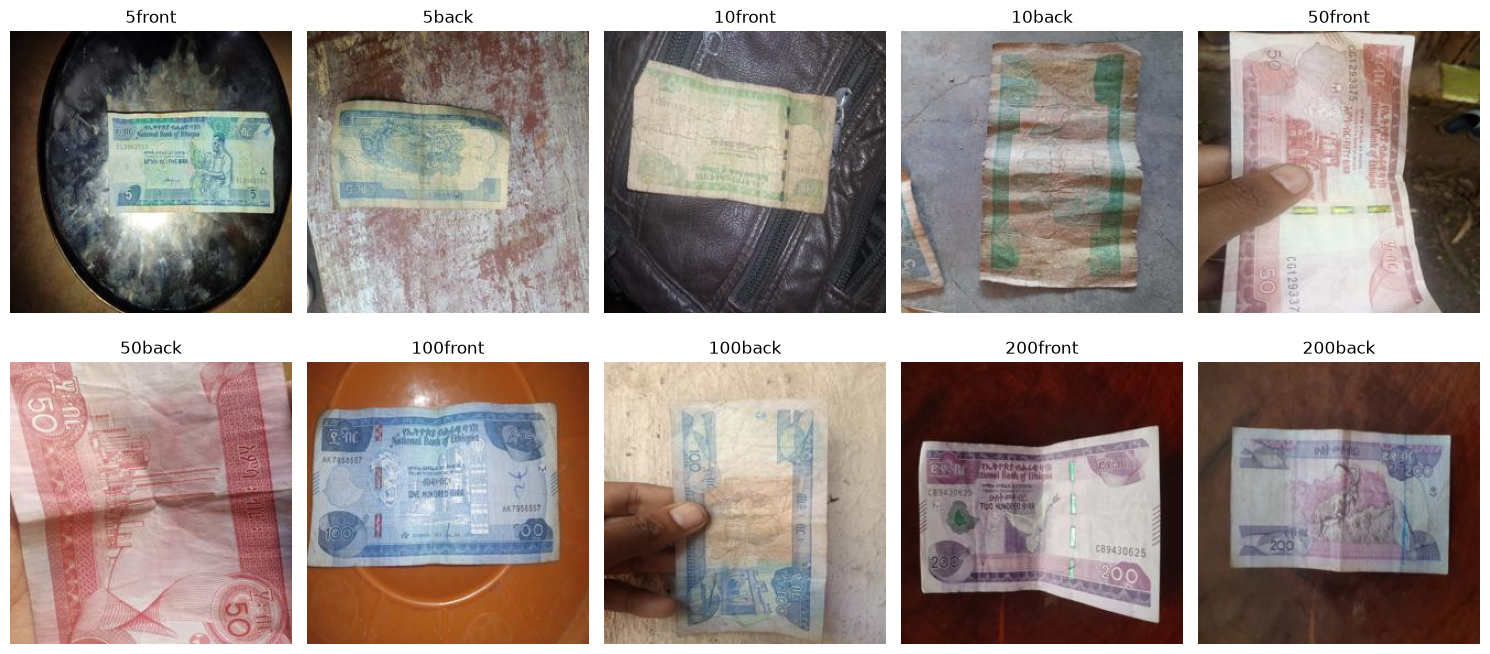

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

folders = [
    "5front",
    "5back",
    "10front",
    "10back",
    "50front",
    "50back",
    "100front",
    "100back",
    "200front",
    "200back"
]

for ax, folder in zip(axes.flatten(), folders):
    folder_path = os.path.join(TRAIN_DIR, folder)

    images = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(folder_path, images[0])
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(folder)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Label Mapping

In [7]:
CLASS_MAPPING = {
    "5front": 0,
    "5back": 0,

    "10front": 1,
    "10back": 1,

    "50front": 2,
    "50back": 2,

    "100front": 3,
    "100back": 3,

    "200front": 4,
    "200back": 4,

    # Natural Images → Other
    "airplane": 5,
    "car": 5,
    "cat": 5,
    "dog": 5,
    "flower": 5,
    "fruit": 5,
    "motorbike": 5,
    "person": 5
}

CLASS_NAMES = [
    "5 Birr",
    "10 Birr",
    "50 Birr",
    "100 Birr",
    "200 Birr",
    "Other"
]

#### Choose Image Size

In [8]:
IMG_SIZE = (224, 224)

#### Load the images

In [9]:
def load_folder_images(directory, class_mapping):
    images = []
    labels = []

    for folder in sorted(os.listdir(directory)):

        folder_path = os.path.join(directory, folder)

        if not os.path.isdir(folder_path):
            continue

        if folder not in class_mapping:
            continue

        label = class_mapping[folder]

        for file in os.listdir(folder_path):

            if not file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                continue

            image_path = os.path.join(folder_path, file)

            try:
                image = Image.open(image_path).convert("RGB")
                image = image.resize(IMG_SIZE)

                images.append(np.array(image))
                labels.append(label)

            except Exception as e:
                print(f"Could not load {image_path}: {e}")

    return np.array(images), np.array(labels)

#### Load Training and Testing Dataset

In [10]:
X_birr_train, y_birr_train = load_folder_images(
    TRAIN_DIR,
    CLASS_MAPPING
)

X_birr_test, y_birr_test = load_folder_images(
    TEST_DIR,
    CLASS_MAPPING
)

print("Birr training:", X_birr_train.shape)
print("Birr testing:", X_birr_test.shape)

Birr training: (1480, 224, 224, 3)
Birr testing: (360, 224, 224, 3)


#### Load Natural Images

In [11]:
NATURAL_CLASS_MAPPING = {
    "airplane": 5,
    "car": 5,
    "cat": 5,
    "dog": 5,
    "flower": 5,
    "fruit": 5,
    "motorbike": 5,
    "person": 5
}

In [12]:
X_other, y_other = load_folder_images(
    NATURAL_IMAGES_DIR,
    NATURAL_CLASS_MAPPING
)

print("Other images:", X_other.shape)
print("Other labels:", y_other.shape)

Other images: (6899, 224, 224, 3)
Other labels: (6899,)


#### Split Natural Images to train and test split

In [13]:
X_other_train, X_other_test, y_other_train, y_other_test = train_test_split(
    X_other,
    y_other,
    test_size=0.20,
    random_state=42
)

#### Combine Birr and Other

In [14]:
X_train = np.concatenate(
    [X_birr_train, X_other_train],
    axis=0
)

y_train = np.concatenate(
    [y_birr_train, y_other_train],
    axis=0
)

X_test = np.concatenate(
    [X_birr_test, X_other_test],
    axis=0
)

y_test = np.concatenate(
    [y_birr_test, y_other_test],
    axis=0
)

In [15]:
print("Final training set:", X_train.shape)
print("Final testing set:", X_test.shape)

print("Training labels:", np.unique(y_train, return_counts=True))
print("Testing labels:", np.unique(y_test, return_counts=True))

Final training set: (6999, 224, 224, 3)
Final testing set: (1740, 224, 224, 3)
Training labels: (array([0, 1, 2, 3, 4, 5]), array([ 296,  296,  296,  296,  296, 5519]))
Testing labels: (array([0, 1, 2, 3, 4, 5]), array([  72,   72,   72,   72,   72, 1380]))


#### Normalize the images

In [16]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [17]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


#### Class Distribution

In [18]:
# Training Set
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{CLASS_NAMES[label]}: {count}")

5 Birr: 296
10 Birr: 296
50 Birr: 296
100 Birr: 296
200 Birr: 296
Other: 5519


In [19]:
# Testing Set
unique, counts = np.unique(y_test, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{CLASS_NAMES[label]}: {count}")

5 Birr: 72
10 Birr: 72
50 Birr: 72
100 Birr: 72
200 Birr: 72
Other: 1380


- Both the training and testing sets are balanced.

#### Create a validation set

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [21]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (5599, 224, 224, 3) (5599,)
Validation: (1400, 224, 224, 3) (1400,)
Testing: (1740, 224, 224, 3) (1740,)


#### Data Augmentation

In [22]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
], name="data_augmentation")

#### Visualize augmentation

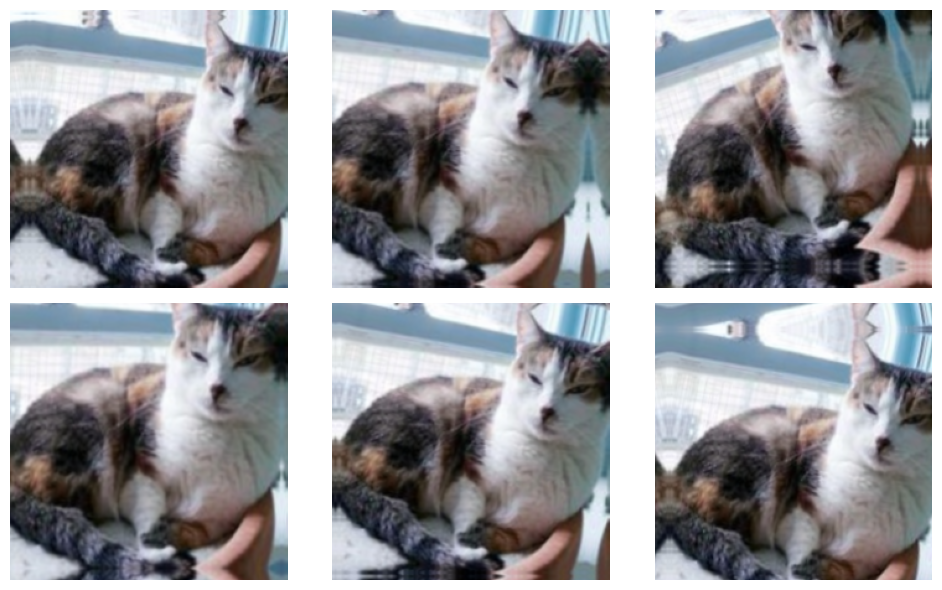

In [23]:
plt.figure(figsize=(10, 6))

sample_image = X_train[0]

for i in range(6):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image[0])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Build the CNN

In [24]:
model = keras.Sequential([
    
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
])

#### Examine the model

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

#### Compile the model

In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#### Callbacks

In [27]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

#### Train the CNN

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks =[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.8101 - loss: 0.5871 - val_accuracy: 0.0850 - val_loss: 2.2263 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - accuracy: 0.8568 - loss: 0.4052 - val_accuracy: 0.7907 - val_loss: 0.5741 - learning_rate: 0.0010
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.8839 - loss: 0.3304 - val_accuracy: 0.8829 - val_loss: 0.3433 - learning_rate: 0.0010
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9027 - loss: 0.2807 - val_accuracy: 0.9129 - val_loss: 0.2392 - learning_rate: 0.0010
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9123 - loss: 0.2543 - val_accuracy: 0.7507 - val_loss: 0.6982 - learning_rate: 0.0010
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9205 - loss: 0.2163 - val_accuracy: 0.8807 - val_loss: 0.3657 - learning_rate: 0.0010
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.9484 - loss: 0.

#### Plot training performance

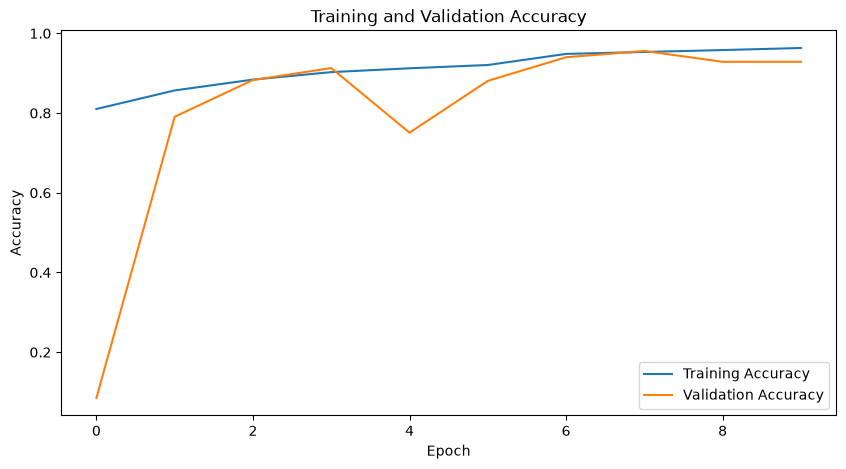

In [29]:
# Accuracy
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

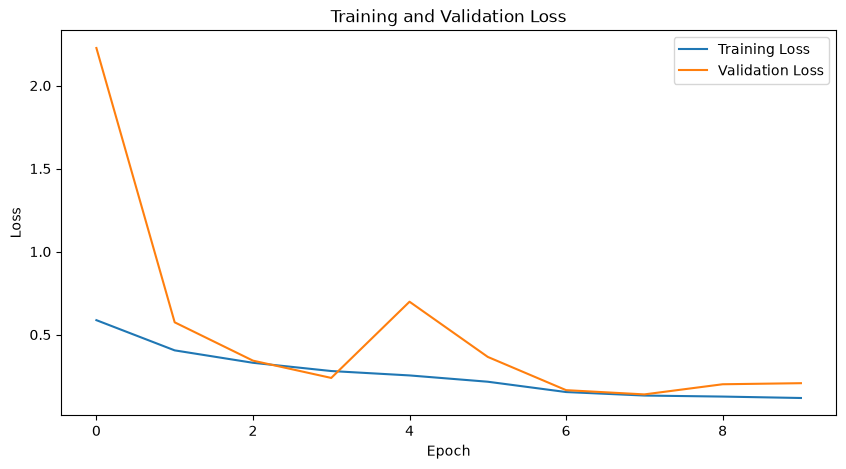

In [30]:
# Loss
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

#### Evaluate on test set

In [31]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 281ms/step - accuracy: 0.9523 - loss: 0.1282
Test Loss: 0.12816980481147766
Test Accuracy: 0.9522988796234131


#### Predictions

In [32]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 284ms/step


#### Classification Report

In [33]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES
    )
)

              precision    recall  f1-score   support

      5 Birr       0.76      0.57      0.65        72
     10 Birr       0.98      0.75      0.85        72
     50 Birr       0.76      0.90      0.82        72
    100 Birr       0.68      0.86      0.76        72
    200 Birr       0.85      0.86      0.86        72
       Other       0.99      0.99      0.99      1380

    accuracy                           0.95      1740
   macro avg       0.84      0.82      0.82      1740
weighted avg       0.96      0.95      0.95      1740



#### Confusion Matrix

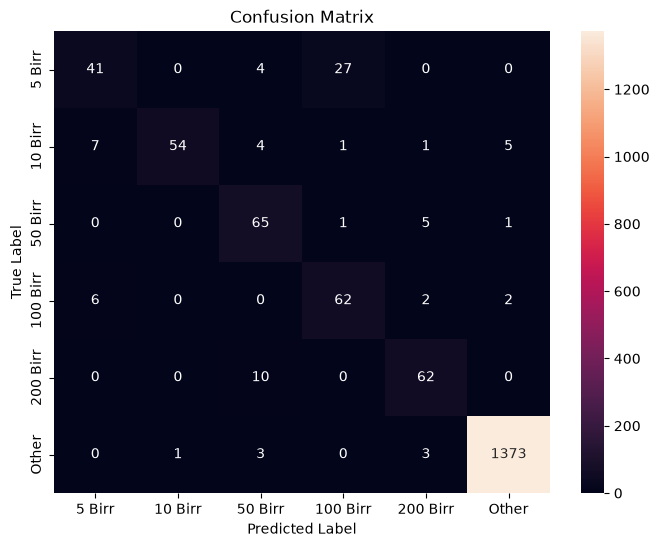

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

#### TRANSFER LEARNING with MobileNetV2

In [35]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

#### Build the classifier

In [36]:
transfer_model = keras.Sequential([
    
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,
    
    layers.Rescaling(2.0, offset=-1),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    
    layers.Dropout(0.3),
    
    layers.Dense(6, activation="softmax")
])

#### Compile the transfer model

In [37]:
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Callbacks

In [39]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

#### Train the model

In [40]:
transfer_history = transfer_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 419ms/step - accuracy: 0.9043 - loss: 0.2710 - val_accuracy: 0.9450 - val_loss: 0.1452 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 451ms/step - accuracy: 0.9612 - loss: 0.1084 - val_accuracy: 0.9671 - val_loss: 0.0849 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 80s 456ms/step - accuracy: 0.9700 - loss: 0.0837 - val_accuracy: 0.9771 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 418ms/step - accuracy: 0.9759 - loss: 0.0658 - val_accuracy: 0.9793 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 445ms/step - accuracy: 0.9818 - loss: 0.0536 - val_accuracy: 0.9800 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 427ms/step - accuracy: 0.9786 - loss: 0.0517 - val_accuracy: 0.9857 - val_loss: 0.0468 - learning_rate: 0.0010
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 493ms/step - accuracy: 0.9

In [41]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Transfer Learning Test Accuracy:", transfer_test_accuracy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 322ms/step - accuracy: 0.9885 - loss: 0.0373
Transfer Learning Test Accuracy: 0.9885057210922241


#### Training Curves

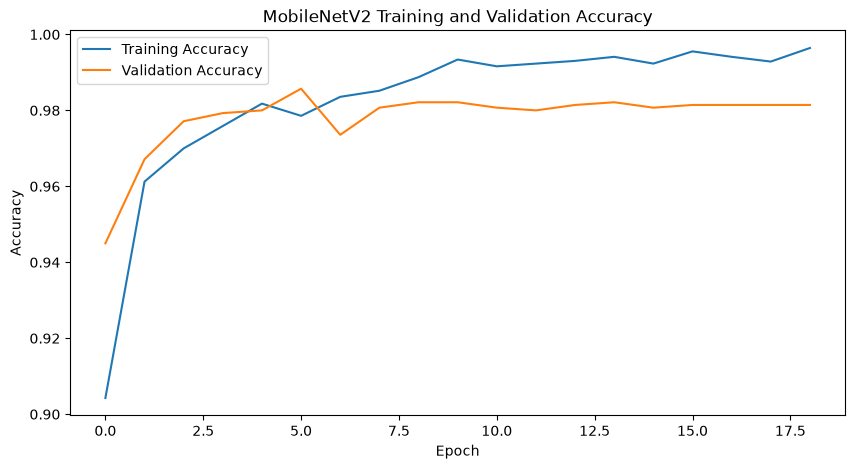

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.show()

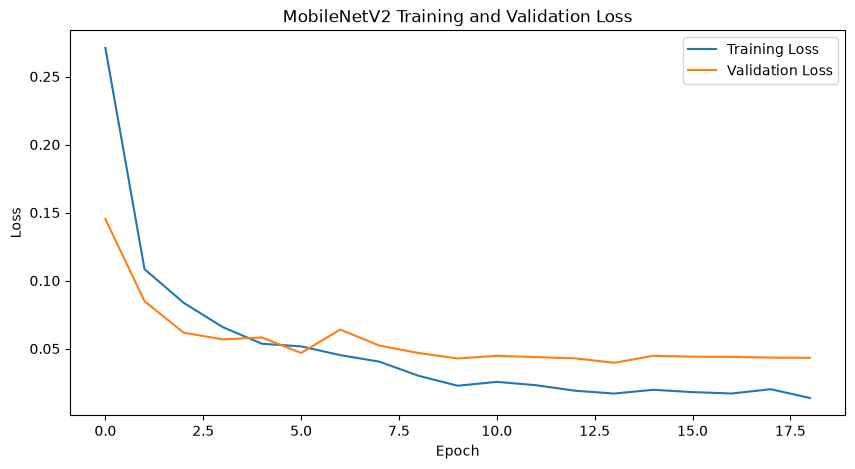

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.show()

#### Classification Report

In [44]:
transfer_pred_prob = transfer_model.predict(X_test)

transfer_pred = np.argmax(
    transfer_pred_prob,
    axis=1
)

print(
    classification_report(
        y_test,
        transfer_pred,
        target_names=CLASS_NAMES
    )
)

55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step
              precision    recall  f1-score   support

      5 Birr       0.88      0.94      0.91        72
     10 Birr       1.00      0.96      0.98        72
     50 Birr       0.99      0.99      0.99        72
    100 Birr       0.93      0.89      0.91        72
    200 Birr       0.93      0.94      0.94        72
       Other       1.00      1.00      1.00      1380

    accuracy                           0.99      1740
   macro avg       0.95      0.95      0.95      1740
weighted avg       0.99      0.99      0.99      1740



#### Confusion Matrix

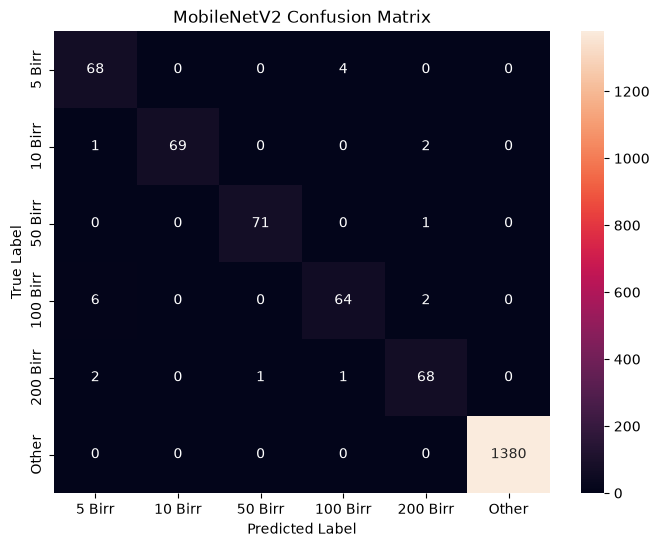

In [45]:
transfer_cm = confusion_matrix(
    y_test,
    transfer_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    transfer_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

#### Save the model

In [46]:
os.makedirs("../models", exist_ok=True)

transfer_model.save("../models/birr_mobilenetv2.keras")

print("Model saved successfully.")

Model saved successfully.
